This notebook is for testing the new module I made and making sure that the old results agree with the new ones

In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import sys
sys.path.append("../discretized-causalpfn")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from discretize import DataDiscretizer
from inference import DiscreteCausalPFN
from scipy.interpolate import interp1d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

## Uniform binning

In [3]:
# Parameters
scheme = "uniform"
comparison_method = "sequential"
N_DISC_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [4]:
# DGP
data_name = "vahid-linear"
np.random.seed(42)
n, d = 2000, 3
X = np.random.normal(1, 1, size=(n, d)).astype(np.float32)
T = (X[:, 0] - X[:, 1] + 2 * X[:, 2] + 2 + np.random.normal(0, 3, size=n)).astype(np.float32)
T = T - T.min() # Rescale
T = T / T.max() # Rescale
Y = (3 * X[:, 0] + X[:, 1] - 0.5 * X[:, 2] + 3 * T + np.random.normal(0, 2, size=n)).astype(np.float32)
def drf(t): return 3.5 + 3 * t # true dose-response function

In [11]:
# Inference
epos_collection = dict() # collect all results across all N_DISC in N_DISC_VALUES
for N_DISC in N_DISC_VALUES:
    print(f"N_DISC: {N_DISC}")
    discretizer = DataDiscretizer(scheme=scheme)
    T_discrete, T_vals = discretizer.discretize_treatment(T, N_DISC)
    model = DiscreteCausalPFN(
        comparison_method=comparison_method,
        N_DISC=N_DISC,
        device=device,
        verbose=True
    )
    epos_dict = model.predict_epos(
        X,
        T_discrete, 
        Y, 
        discrete_treatment_vals=T_vals,
        take_mean=True
    )
    epos_collection[N_DISC] = epos_dict

N_DISC: 2


Predicting CEPO: 100%|██████████| 4000/4000 [00:03<00:00, 1164.48it/s]


N_DISC: 3


Predicting CEPO: 100%|██████████| 3790/3790 [00:04<00:00, 834.13it/s]


N_DISC: 4


...

Predicting CEPO: 100%|██████████| 16/16 [00:00<00:00, 251.89it/s]


N_DISC: 22


Predicting CEPO: 100%|██████████| 14/14 [00:00<00:00, 179.92it/s]


N_DISC: 23


Predicting CEPO: 100%|██████████| 12/12 [00:00<00:00, 188.67it/s]


In [14]:
fine_t_mesh = np.linspace(0, 1, 100)

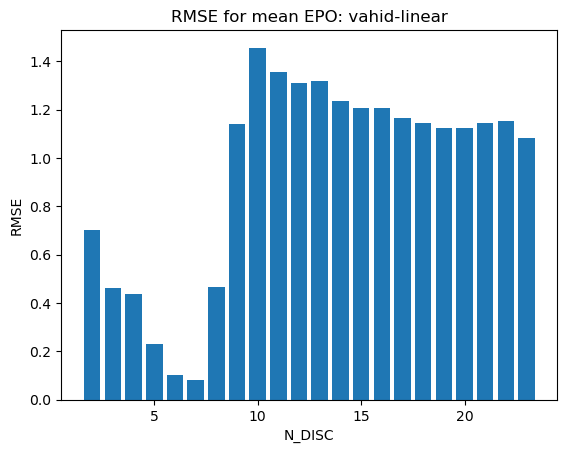

In [15]:
# RMSE calculation on the average EPO

def drf_linear(t): return 3.5 + 3 * t # true dose-response function

rmse_dict = dict()
for N_DISC in N_DISC_VALUES:
    epos_dict = epos_collection[N_DISC]
    # Extract data and plot it 
    lists = sorted(epos_dict.items()) # sorted by key, return a list of tuples
    t_vals, epos = zip(*lists) # unpack a list of pairs into two tuples
    drf_pred = interp1d(t_vals, epos, 
                        bounds_error=False, 
                        fill_value=(epos[0], epos[-1]))
    y_pred = drf_pred(fine_t_mesh)
    y_true = drf_linear(fine_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")

plt.show()

Looks good!!!

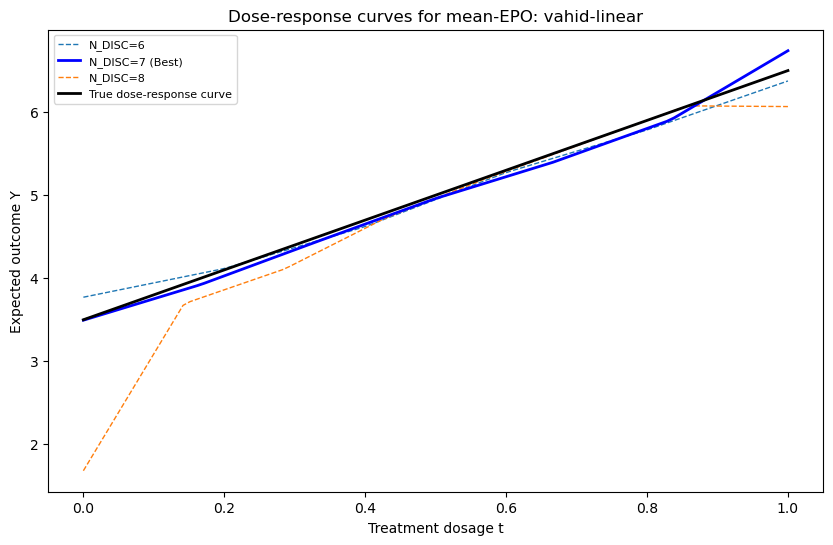

In [19]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [6, 7, 8]
for N_DISC in N_DISC_TO_VIZ:
    epos_dict = epos_collection[N_DISC]
    # Extract data and plot it 
    lists = sorted(epos_dict.items()) # sorted by key, return a list of tuples
    t_vals, epos = zip(*lists) # unpack a list of pairs into two tuples
    drf_pred = interp1d(t_vals, epos, 
                        bounds_error=False, 
                        fill_value=(epos[0], epos[-1]))
    y_pred = drf_pred(fine_t_mesh)
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(fine_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(fine_t_mesh, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
y_true = drf_linear(fine_t_mesh)
plt.plot(fine_t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO: {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)

plt.show()

Looks great!!!